In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [2]:
TRAIN_LOG_PATH = "data/processed/train_log_processed.parquet"
TEST_LOG_PATH = "data/processed/test_log_processed.parquet"

TRAIN_TREE_PATH = "data/processed/train_tree_processed.parquet"
TEST_TREE_PATH = "data/processed/test_tree_processed.parquet"

TARGET = "is_fraud"
RANDOM_STATE = 42

In [3]:
log_train_df = pd.read_parquet(TRAIN_LOG_PATH)
log_test_df = pd.read_parquet(TEST_LOG_PATH)
print("=== Logistic data ===")
print("Logistic train shape:", log_train_df.shape)
print("Logistic test shape :", log_test_df.shape)
print("Columns match:", list(log_train_df.columns) == list(log_test_df.columns))
print("Missing train:", log_train_df.isna().sum().sum())
print("Missing test :", log_test_df.isna().sum().sum())


tree_train_df = pd.read_parquet(TRAIN_TREE_PATH)
tree_test_df = pd.read_parquet(TEST_TREE_PATH)
print("\n=== Tree data ===")
print("Tree train shape:", tree_train_df.shape)
print("Tree test shape :", tree_test_df.shape)
print("Columns match:", list(tree_train_df.columns) == list(tree_test_df.columns))
print("Missing train:", tree_train_df.isna().sum().sum())
print("Missing test :", tree_test_df.isna().sum().sum())

=== Logistic data ===
Logistic train shape: (666085, 96)
Logistic test shape : (166413, 96)
Columns match: True
Missing train: 0
Missing test : 0

=== Tree data ===
Tree train shape: (666085, 27)
Tree test shape : (166413, 27)
Columns match: True
Missing train: 0
Missing test : 0


# X / y Split

In [5]:
X_train_log = log_train_df.drop(columns=[TARGET]).copy()
y_train_log = log_train_df[TARGET].astype(int).copy()

X_test_log = log_test_df.drop(columns=[TARGET]).copy()
y_test_log = log_test_df[TARGET].astype(int).copy()

print("X_train_log:", X_train_log.shape)
print("X_test_log :", X_test_log.shape)

X_train_tree = tree_train_df.drop(columns=[TARGET]).copy()
y_train_tree = tree_train_df[TARGET].astype(int).copy()

X_test_tree = tree_test_df.drop(columns=[TARGET]).copy()
y_test_tree = tree_test_df[TARGET].astype(int).copy()

print("X_train_tree:", X_train_tree.shape)
print("X_test_tree :", X_test_tree.shape)

X_train_log: (666085, 94)
X_test_log : (166413, 94)
X_train_tree: (666085, 25)
X_test_tree : (166413, 25)


In [6]:
# Logistic
log_bool_cols_train = X_train_log.select_dtypes(include="bool").columns.tolist()
log_bool_cols_test = X_test_log.select_dtypes(include="bool").columns.tolist()

X_train_log[log_bool_cols_train] = X_train_log[log_bool_cols_train].astype(int)
X_test_log[log_bool_cols_test] = X_test_log[log_bool_cols_test].astype(int)

# Tree
tree_bool_cols_train = X_train_tree.select_dtypes(include="bool").columns.tolist()
tree_bool_cols_test = X_test_tree.select_dtypes(include="bool").columns.tolist()

X_train_tree[tree_bool_cols_train] = X_train_tree[tree_bool_cols_train].astype(int)
X_test_tree[tree_bool_cols_test] = X_test_tree[tree_bool_cols_test].astype(int)

print("Converted bool columns to int for both branches.")

Converted bool columns to int for both branches.


In [7]:
def compute_binary_metrics(y_true, y_pred, y_score):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
    }

def print_model_report(model_name, y_true, y_pred, y_score):
    metrics = compute_binary_metrics(y_true, y_pred, y_score)

    print(f"========== {model_name} ==========")
    for metric_name, metric_value in metrics.items():
        print(f"{metric_name}: {metric_value:.6f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    return metrics

In [8]:
def plot_confusion_matrix(y_true, y_pred, title):
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        ax=ax,
        colorbar=False,
        cmap=plt.cm.Blues   # dùng kiểu này chắc hơn
    )
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    
def plot_top_importance(importance_df, title, top_n=15):
    plot_df = importance_df.head(top_n).sort_values("importance", ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(plot_df["feature"], plot_df["importance"])
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(title)
    plt.tight_layout()
    plt.show()

## Model: Logistic Regression

In [9]:
logistic_model = LogisticRegression(
    max_iter=300,
    solver="liblinear",
    class_weight="balanced",
    random_state=RANDOM_STATE
)

logistic_model.fit(X_train_log, y_train_log)

logistic_y_pred = logistic_model.predict(X_test_log)
logistic_y_score = logistic_model.predict_proba(X_test_log)[:, 1]

========== Logistic Regression ==========
accuracy: 0.941687
precision: 0.221886
recall: 0.936853
f1_score: 0.358795
roc_auc: 0.984287
pr_auc: 0.786175

Confusion Matrix:
[[153994   9521]
 [   183   2715]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9988    0.9418    0.9695    163515
           1     0.2219    0.9369    0.3588      2898

    accuracy                         0.9417    166413
   macro avg     0.6103    0.9393    0.6641    166413
weighted avg     0.9853    0.9417    0.9588    166413



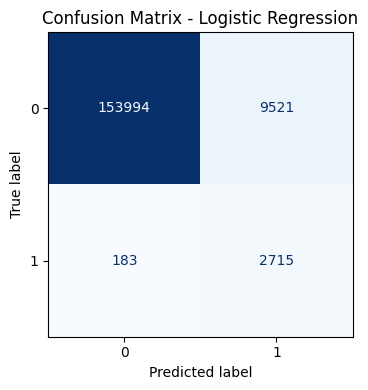

In [10]:
logistic_metrics = print_model_report(
    model_name="Logistic Regression",
    y_true=y_test_log,
    y_pred=logistic_y_pred,
    y_score=logistic_y_score
)

plot_confusion_matrix(
    y_true=y_test_log,
    y_pred=logistic_y_pred,
    title="Confusion Matrix - Logistic Regression"
)

,feature,coefficient,importance
0,device_known,-2.395397,2.395397
1,high_ip_risk_flag,1.578870,1.578870
2,log_velocity_1h,1.535718,1.535718
3,log_amount,1.039934,1.039934
4,mcc_code_4511,-0.701083,0.701083
5,merchant_category_travel,-0.701083,0.701083
6,merchant_category_crypto,-0.689050,0.689050
7,mcc_code_6051,-0.689050,0.689050
8,merchant_category_restaurant,0.617052,0.617052
9,mcc_code_5812,0.617052,0.617052


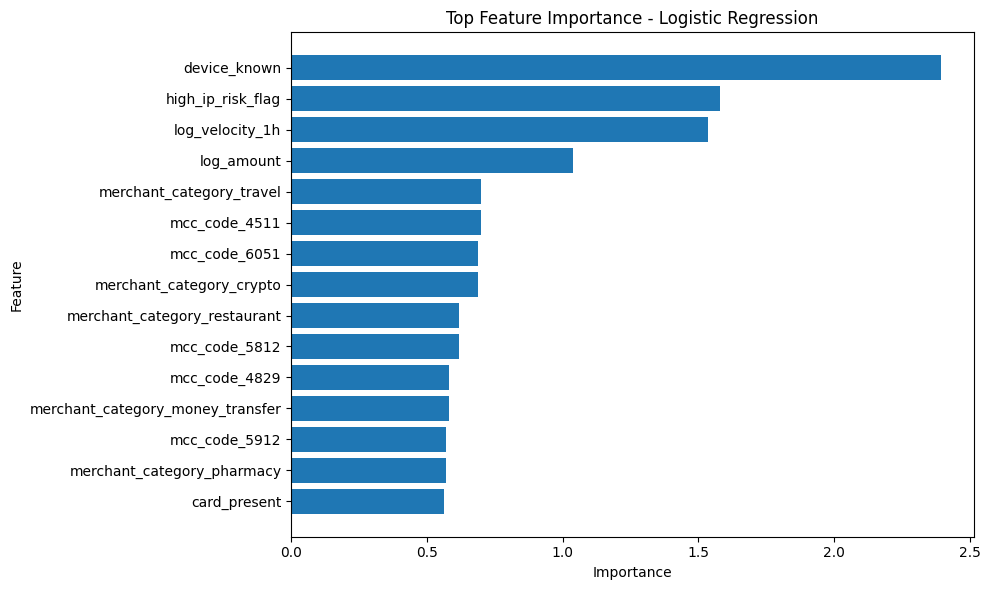

In [11]:
logistic_importance_df = pd.DataFrame({
    "feature": X_train_log.columns,
    "coefficient": logistic_model.coef_[0]
})

logistic_importance_df["importance"] = logistic_importance_df["coefficient"].abs()
logistic_importance_df = logistic_importance_df.sort_values("importance", ascending=False).reset_index(drop=True)

display(logistic_importance_df.head(20))

plot_top_importance(
    logistic_importance_df[["feature", "importance"]],
    "Top Feature Importance - Logistic Regression",
    top_n=15
)

## Model: Tree Models

In [12]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

lgbm_model = LGBMClassifier(
    n_estimators=300,
    max_depth=-1,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

cat_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=RANDOM_STATE,
    verbose=0
)

In [13]:
# Train XGBoost
xgb_model.fit(X_train_tree, y_train_tree)

xgb_y_pred = xgb_model.predict(X_test_tree)
xgb_y_score = xgb_model.predict_proba(X_test_tree)[:, 1]

xgb_metrics = print_model_report(
    model_name="XGBoost",
    y_true=y_test_tree,
    y_pred=xgb_y_pred,
    y_score=xgb_y_score
)

# Train LightGBM
lgbm_model.fit(X_train_tree, y_train_tree)

lgbm_y_pred = lgbm_model.predict(X_test_tree)
lgbm_y_score = lgbm_model.predict_proba(X_test_tree)[:, 1]

lgbm_metrics = print_model_report(
    model_name="LightGBM",
    y_true=y_test_tree,
    y_pred=lgbm_y_pred,
    y_score=lgbm_y_score
)

# Train CatBoost
cat_model.fit(X_train_tree, y_train_tree)

cat_y_pred = cat_model.predict(X_test_tree)
cat_y_pred = np.array(cat_y_pred).reshape(-1).astype(int)

cat_y_score = cat_model.predict_proba(X_test_tree)[:, 1]

cat_metrics = print_model_report(
    model_name="CatBoost",
    y_true=y_test_tree,
    y_pred=cat_y_pred,
    y_score=cat_y_score
)

========== XGBoost ==========
accuracy: 0.992080
precision: 0.855856
recall: 0.655625
f1_score: 0.742478
roc_auc: 0.987621
pr_auc: 0.818950

Confusion Matrix:
[[163195    320]
 [   998   1900]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9939    0.9980    0.9960    163515
           1     0.8559    0.6556    0.7425      2898

    accuracy                         0.9921    166413
   macro avg     0.9249    0.8268    0.8692    166413
weighted avg     0.9915    0.9921    0.9916    166413

[LightGBM] [Info] Number of positive: 11418, number of negative: 654667
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031992 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1389
[LightGBM] [Info] Number of data points in the train set: 666085, number of used features: 25
[LightGBM] [Info] [binary:Boo

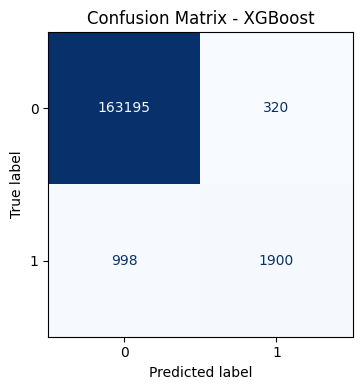

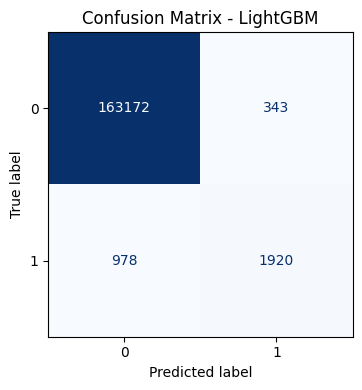

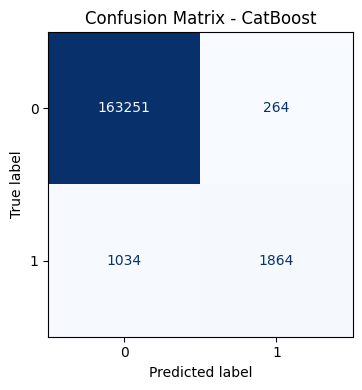

In [14]:
plot_confusion_matrix(y_test_tree, xgb_y_pred, "Confusion Matrix - XGBoost")
plot_confusion_matrix(y_test_tree, lgbm_y_pred, "Confusion Matrix - LightGBM")
plot_confusion_matrix(y_test_tree, cat_y_pred, "Confusion Matrix - CatBoost")

In [15]:
xgb_importance_df = pd.DataFrame({
    "feature": X_train_tree.columns,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

lgbm_importance_df = pd.DataFrame({
    "feature": X_train_tree.columns,
    "importance": lgbm_model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

cat_importance_df = pd.DataFrame({
    "feature": X_train_tree.columns,
    "importance": cat_model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

## Two-level ensemble stacking

In [16]:
from sklearn.ensemble import StackingClassifier

In [17]:
stacking_model = StackingClassifier(
    estimators=[
        ("xgb", xgb_model),
        ("lgbm", lgbm_model),
        ("cat", cat_model),
    ],
    final_estimator=logistic_model,
    stack_method="predict_proba",
    cv=5,
    passthrough=False,
    n_jobs=-1
)

stacking_model

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('xgb', ...), ('lgbm', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...r='liblinear')
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'predict_proba'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use prede

In [18]:
stacking_model.fit(X_train_tree, y_train_tree)

stacking_y_pred = stacking_model.predict(X_test_tree)
stacking_y_score = stacking_model.predict_proba(X_test_tree)[:, 1]

========== Stacking Ensemble (Tree Level-1 + Logistic Level-2) ==========
accuracy: 0.979016
precision: 0.447619
recall: 0.875776
f1_score: 0.592437
roc_auc: 0.987746
pr_auc: 0.819837

Confusion Matrix:
[[160383   3132]
 [   360   2538]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9978    0.9808    0.9892    163515
           1     0.4476    0.8758    0.5924      2898

    accuracy                         0.9790    166413
   macro avg     0.7227    0.9283    0.7908    166413
weighted avg     0.9882    0.9790    0.9823    166413



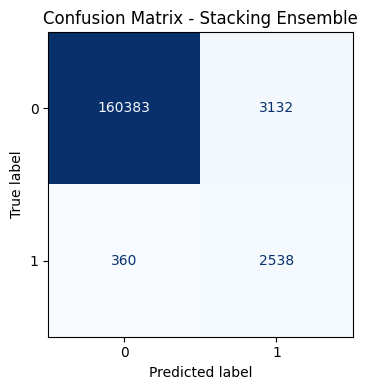

In [19]:
stacking_metrics = print_model_report(
    model_name="Stacking Ensemble (Tree Level-1 + Logistic Level-2)",
    y_true=y_test_tree,
    y_pred=stacking_y_pred,
    y_score=stacking_y_score
)

plot_confusion_matrix(
    y_true=y_test_tree,
    y_pred=stacking_y_pred,
    title="Confusion Matrix - Stacking Ensemble"
)

## Compare all models

In [20]:
comparision_model = pd.DataFrame([
    {"model": "Logistic Regression", **logistic_metrics},
    {"model": "XGBoost", **xgb_metrics},
    {"model": "LightGBM", **lgbm_metrics},
    {"model": "CatBoost", **cat_metrics},
    {"model": "Stacking Ensemble", **stacking_metrics},
])

comparision_model = comparision_model.sort_values("pr_auc", ascending=False).reset_index(drop=True)
display(comparision_model)

,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,CatBoost,0.992200,0.875940,0.643202,0.741743,0.987779,0.820080
1,Stacking Ensemble,0.979016,0.447619,0.875776,0.592437,0.987746,0.819837
2,XGBoost,0.992080,0.855856,0.655625,0.742478,0.987621,0.818950
3,LightGBM,0.992062,0.848431,0.662526,0.744042,0.987128,0.813929
4,Logistic Regression,0.941687,0.221886,0.936853,0.358795,0.984287,0.786175


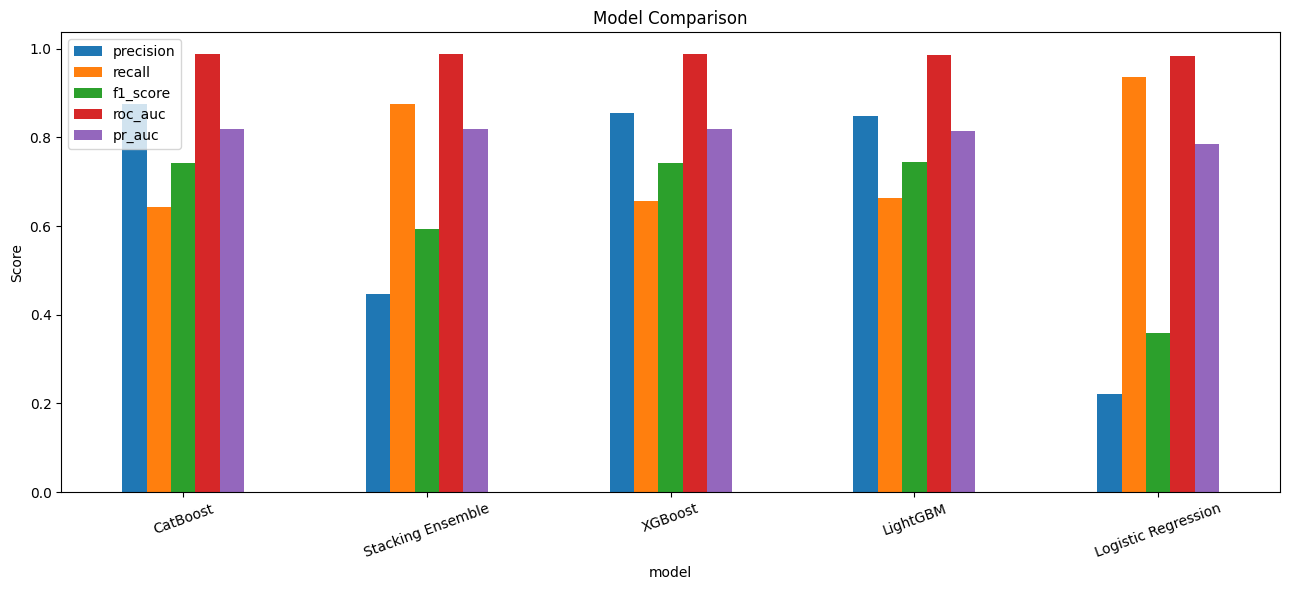

In [21]:
metrics_to_plot = ["precision", "recall", "f1_score", "roc_auc", "pr_auc"]

plot_df = comparision_model.set_index("model")[metrics_to_plot]

plot_df.plot(kind="bar", figsize=(13, 6))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

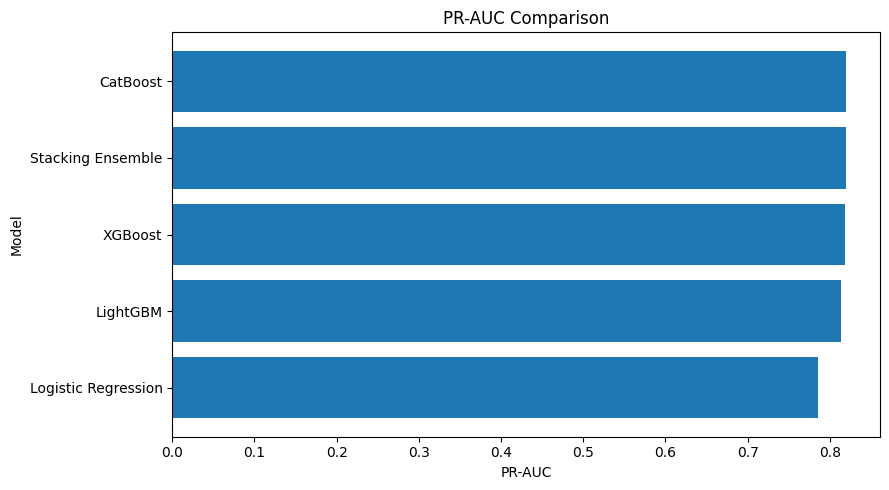

In [22]:
pr_auc_df = comparision_model.sort_values("pr_auc", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(pr_auc_df["model"], pr_auc_df["pr_auc"])
plt.xlabel("PR-AUC")
plt.ylabel("Model")
plt.title("PR-AUC Comparison")
plt.tight_layout()
plt.show()

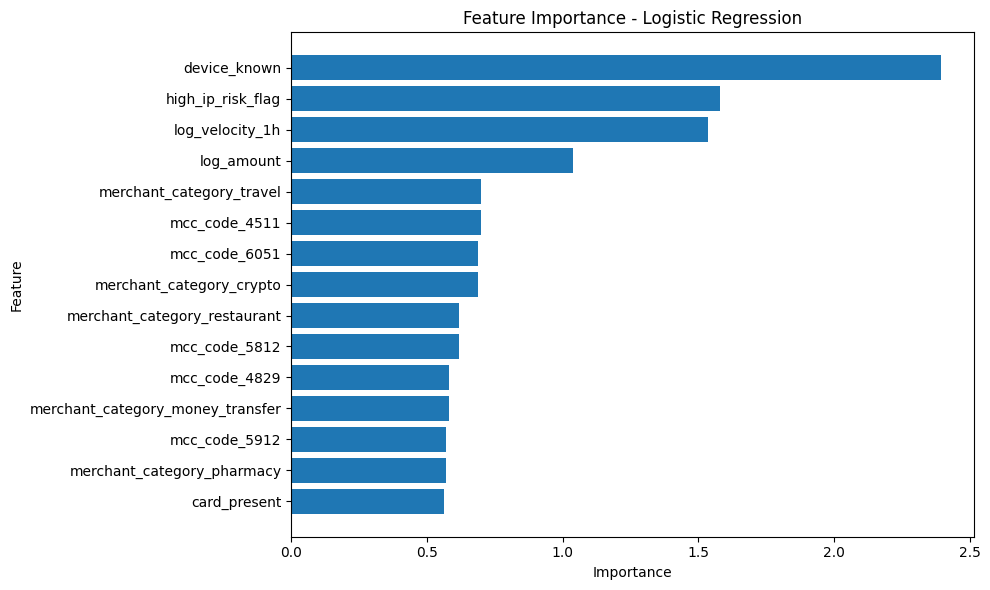

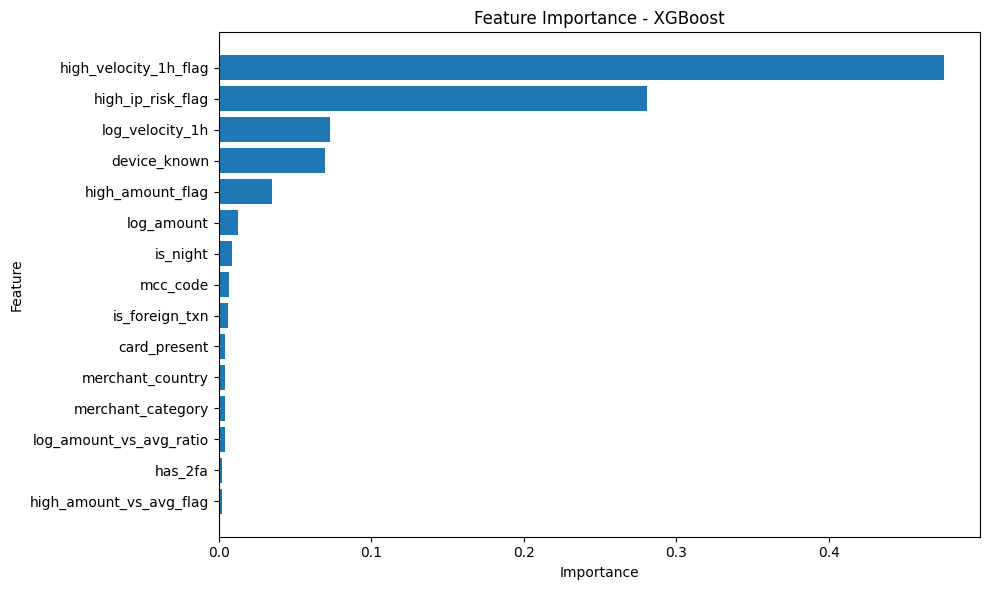

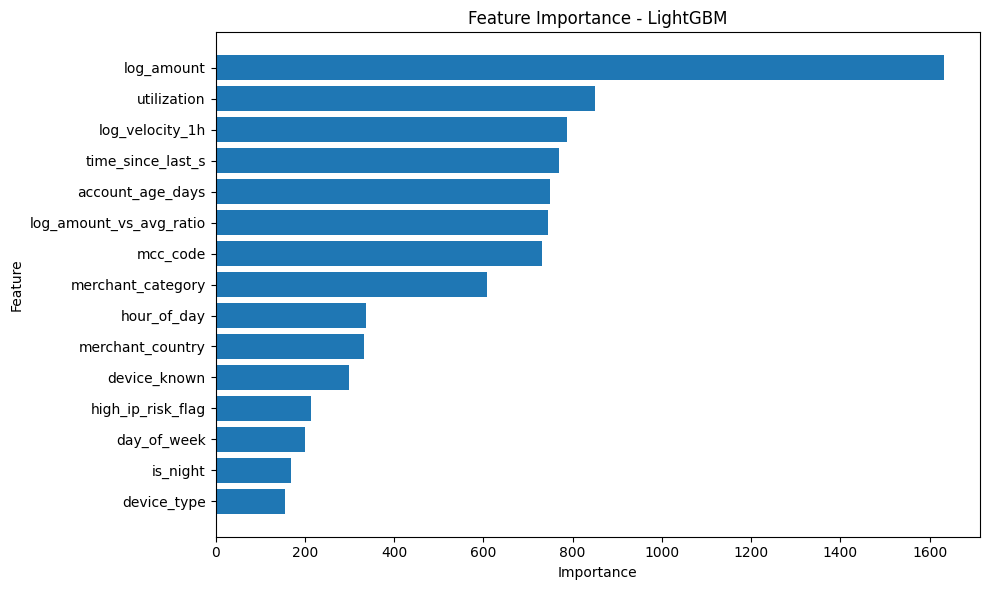

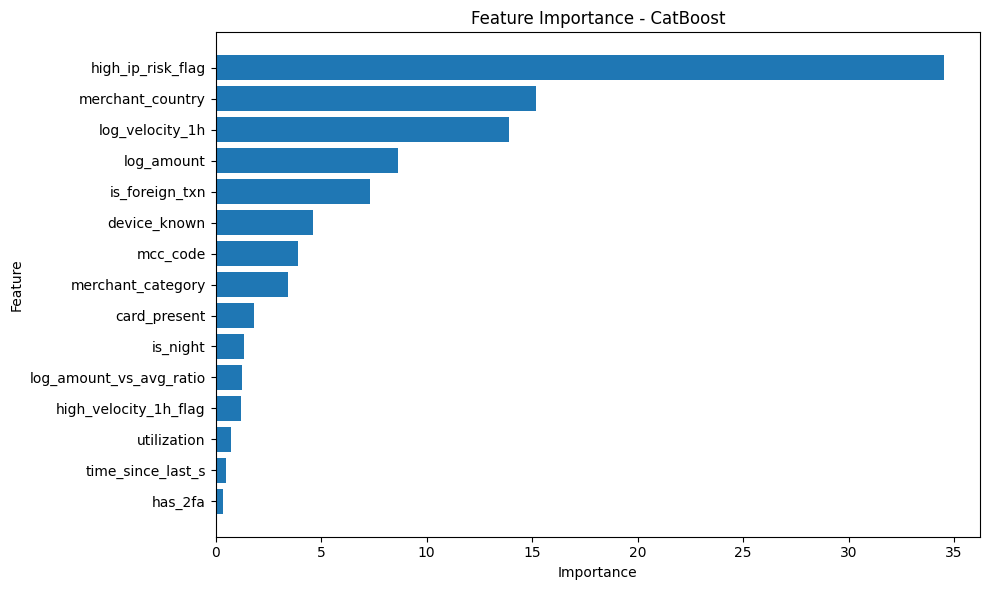

In [23]:
plot_top_importance(logistic_importance_df[["feature", "importance"]], "Feature Importance - Logistic Regression", top_n=15)
plot_top_importance(xgb_importance_df, "Feature Importance - XGBoost", top_n=15)
plot_top_importance(lgbm_importance_df, "Feature Importance - LightGBM", top_n=15)
plot_top_importance(cat_importance_df, "Feature Importance - CatBoost", top_n=15)

In [24]:
top_features_summary = pd.DataFrame({
    "Logistic": logistic_importance_df.head(15)["feature"].tolist(),
    "XGBoost": xgb_importance_df.head(15)["feature"].tolist(),
    "LightGBM": lgbm_importance_df.head(15)["feature"].tolist(),
    "CatBoost": cat_importance_df.head(15)["feature"].tolist(),
})

display(top_features_summary)

,Logistic,XGBoost,LightGBM,CatBoost
0,device_known,high_velocity_1h_flag,log_amount,high_ip_risk_flag
1,high_ip_risk_flag,high_ip_risk_flag,utilization,merchant_country
2,log_velocity_1h,log_velocity_1h,log_velocity_1h,log_velocity_1h
3,log_amount,device_known,time_since_last_s,log_amount
4,mcc_code_4511,high_amount_flag,account_age_days,is_foreign_txn
5,merchant_category_travel,log_amount,log_amount_vs_avg_ratio,device_known
6,merchant_category_crypto,is_night,mcc_code,mcc_code
7,mcc_code_6051,mcc_code,merchant_category,merchant_category
8,merchant_category_restaurant,is_foreign_txn,hour_of_day,card_present
9,mcc_code_5812,card_present,merchant_country,is_night


In [25]:
best_model_row = comparision_model.sort_values("pr_auc", ascending=False).iloc[0]

print("Best model by PR-AUC:")
display(best_model_row.to_frame().T)

Best model by PR-AUC:


,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,CatBoost,0.9922,0.87594,0.643202,0.741743,0.987779,0.82008
